In [15]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e

#eps = 1
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
delta_ion_2 = 0#-4.9903032463e-14 # small displacement of ion 2
#m_dm = 1e-27
m_ion = c.m 
Z_ion = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega_vec = np.asarray(2*pi*np.array([freq_x,freq_y,freq_z]), dtype=float) 
hbar = 1.0545718e-34 
mode_y = 2*pi*np.array([3031200.01,2944587.06,2818861.50])
mode_z = 2*pi*np.array([3002153.56,2914677.59,2787603.39])

In [16]:
"""
xyz : ndarray, shape (n, 3)
        Particle positions.
"""
# RF pseudo-force
def FRF(xyz,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    m = float(np.asarray(m).ravel()[0])
    Z = float(np.asarray(Z).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z*q)/(2*pi*np.sqrt(m)*omrf))**2*np.column_stack([divypartz*0, divzparty+divyparty, divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,xyz,v): # gradient term of DC potential
    xyz = np.asarray(xyz, dtype=float)
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.column_stack([divx, divy, divz])

def FDC_single(x1,y1,x2,y2,xyz,v,Z,q=c.e):
    return -Z*q * (anatangrad(x2,y2,xyz,v)-anatangrad(x2,y1,xyz,v)-anatangrad(x1,y2,xyz,v)+anatangrad(x1,y1,xyz,v))

def FDC(xyz, m, Z, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    z_original = xyz[:, 2].copy()
    force = np.zeros_like(xyz)
    for k in range(0, 40):
        xyz_k = xyz.copy()
        if (k != 19 and k != 39):
            xyz_k[:, 2] = z_original - z_offset  # keep scalar math
        else:
            xyz_k[:, 2] = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, xyz_k, v_k, Z, q=q)
        # check shape of force_single 
        force_single = np.asarray(force_single, dtype=float)
        if force_single.shape != xyz.shape:
            raise ValueError(
                f"FDC_single returned unexpected shape {force_single.shape}; "
                f"expected {xyz.shape} at k={k}"
            )
        force += force_single
    return force

# Full Simulation Code

In [17]:
def run_simulation_many_dm_single_ion(
    x0_dms, v0_dms, x0_ion, v0_ion,
    t_span, dt, m_dm, eps, run_rutherford,
    rtol=1e-13, atol=1e-16
):
    """
    Run a single-ion / many-DM trajectory simulation.

    This version includes:
        - one trapped ion near the origin
        - many DM particles
        - ion-DM Coulomb forces
        - no DM-DM Coulomb forces

    Parameters
    ----------
    x0_dms : array-like, shape (n_dm, 3)
        Initial positions of the DM particles.

    v0_dms : array-like, shape (n_dm, 3)
        Initial velocities of the DM particles.

    x0_ion : array-like, shape (3,)
        Initial position of the single ion.

    v0_ion : array-like, shape (3,)
        Initial velocity of the single ion.

    t_span : tuple (t_start, t_end)
        Start and end time of the integration.

    dt : float
        Time increment used to build the evaluation grid.

    m_dm : float
        Mass of DM particles in kg.
    
    eps : float
        Charge of DM particles in units of elementary charge.

    run_rutherford : bool
        If True, set trap fields to zero for Rutherford scattering comparison.

    Returns
    -------
    t_eval : ndarray, shape (N,)
        Times at which the solution was evaluated.

    x_ion_sol : ndarray, shape (3, N)
        Ion position trajectory.

    v_ion_sol : ndarray, shape (3, N)
        Ion velocity trajectory.

    x_dms_sol : ndarray, shape (n_dm, 3, N)
        DM position trajectories.

    v_dms_sol : ndarray, shape (n_dm, 3, N)
        DM velocity trajectories.
    """

    x0_dms = np.asarray(x0_dms, dtype=float)
    v0_dms = np.asarray(v0_dms, dtype=float)
    x0_ion = np.asarray(x0_ion, dtype=float)
    v0_ion = np.asarray(v0_ion, dtype=float)

    if x0_dms.ndim != 2 or x0_dms.shape[1] != 3:
        raise ValueError("x0_dms must have shape (n_dm, 3)")

    if v0_dms.shape != x0_dms.shape:
        raise ValueError("v0_dms must have the same shape as x0_dms")

    if x0_ion.shape != (3,):
        raise ValueError("x0_ion must have shape (3,)")

    if v0_ion.shape != (3,):
        raise ValueError("v0_ion must have shape (3,)")

    n_dm = x0_dms.shape[0]

    # The single ion is trapped about the origin.
    r_ion_eq = np.zeros(3, dtype=float)

    def rhs_unified(t, U, r_ion_eq, use_harmonic_ion=True):
        """
        State vector layout:

        U = [
            x_ion(3),
            x_dms(3*n_dm),
            v_ion(3),
            v_dms(3*n_dm)
        ]
        """

        idx0 = 0
        idx1 = idx0 + 3
        idx2 = idx1 + 3 * n_dm
        idx3 = idx2 + 3
        idx4 = idx3 + 3 * n_dm

        x_ion = U[idx0:idx1]
        x_dms = U[idx1:idx2].reshape((n_dm, 3))

        v_ion = U[idx2:idx3]
        v_dms = U[idx3:idx4].reshape((n_dm, 3))

        dx_iondt = v_ion
        dx_dmsdt = v_dms

        dv_iondt = np.zeros(3)
        dv_dmsdt = np.zeros((n_dm, 3))

        # --------------------------------------------------
        # Trap force acting on ion
        # --------------------------------------------------
        if use_harmonic_ion:
            if run_rutherford:
                dv_iondt += np.zeros(3)
            else:
                dv_iondt += -omega_vec**2 * (x_ion - r_ion_eq)
        else:
            if not run_rutherford:
                x_ion_arr = x_ion[None, :]
                F_dc_ion = FDC(x_ion_arr, m=m_ion, Z=Z_ion)[0]
                F_rf_ion = FRF(x_ion_arr, m=m_ion, Z=Z_ion)[0]
                F_ion = F_dc_ion + F_rf_ion
                dv_iondt += F_ion / m_ion

        # --------------------------------------------------
        # Trap force acting on each DM particle
        # --------------------------------------------------
        if not run_rutherford:
            F_dc_dms = FDC(x_dms, m_dm, eps)
            F_rf_dms = FRF(x_dms, m_dm, eps)

            dv_dmsdt += (F_dc_dms + F_rf_dms) / m_dm

        # --------------------------------------------------
        # Coulomb interactions: ion <-> each DM particle
        #
        # No DM-DM Coulomb forces are included.
        # --------------------------------------------------
        delta = x_ion[None, :] - x_dms
        r = np.linalg.norm(delta, axis=1)

        forces = K * Z_ion * eps * e**2 * delta / r[:, None]**3

        # Force on ion due to DM k
        dv_iondt += forces.sum(axis=0) / m_ion

        # Equal and opposite force on DM k due to ion
        dv_dmsdt -= forces / m_dm

        return np.concatenate([
            dx_iondt,
            dx_dmsdt.flatten(),
            dv_iondt,
            dv_dmsdt.flatten()
        ])

    print("Number of DM particles:", n_dm)
    print("Initial ion position:", x0_ion)
    print("Initial ion velocity:", v0_ion)

    # Initial state
    U0 = np.concatenate([
        x0_ion,
        x0_dms.flatten(),
        v0_ion,
        v0_dms.flatten()
    ]).astype(float)

    # Time grid
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(
        rhs_unified,
        t_span,
        U0,
        method="DOP853",
        t_eval=t_eval,
        dense_output=True,
        rtol=rtol,
        atol=atol,
        max_step=dt,
        args=(r_ion_eq,)
    )

    print("Success?", sol.success)
    print("Message:", sol.message)

    if sol.t.size > 0:
        print("Final time:", sol.t[-1])

    # Extract solution
    idx0 = 0
    idx1 = idx0 + 3
    idx2 = idx1 + 3 * n_dm
    idx3 = idx2 + 3
    idx4 = idx3 + 3 * n_dm

    x_ion_sol = sol.y[idx0:idx1]
    x_dms_flat_sol = sol.y[idx1:idx2]

    v_ion_sol = sol.y[idx2:idx3]
    v_dms_flat_sol = sol.y[idx3:idx4]

    # Convert flattened DM solution into shape (n_dm, 3, N)
    n_t = sol.y.shape[1]

    x_dms_sol = x_dms_flat_sol.reshape((n_dm, 3, n_t))
    v_dms_sol = v_dms_flat_sol.reshape((n_dm, 3, n_t))

    return t_eval, x_ion_sol, v_ion_sol, x_dms_sol, v_dms_sol

In [18]:
def analyze_simulation_results(x0_dms, v0_dms, x0_ion, v0_ion, t_span, dt, t_min, m_dm, eps, fit_curve, rutherford, show_plots,
                                rtol, atol):
    # default rtol=1e-13, atol=1e-16
    if(rutherford):
        t00, xion00, vion00, xdms00, vdms00 = run_simulation_many_dm_single_ion(x0_dms, v0_dms, x0_ion, v0_ion, t_span, dt, m_dm, eps, run_rutherford=True, rtol=rtol, atol=atol)
    else:
        t00, xion00, vion00, xdms00, vdms00 = run_simulation_many_dm_single_ion(x0_dms, v0_dms, x0_ion, v0_ion, t_span, dt, m_dm, eps, run_rutherford=False, rtol=rtol, atol=atol)
    t0 = t00/um
    xion0 = xion00/um
    vion0 = vion00
    xdms0 = xdms00/um
    vdms0 = vdms00
    x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of center ion

    ## Plots 
    if(show_plots):

        # -------------------------
        # Ion coordinates vs time
        # -------------------------
        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.plot(t0, x0_ion1, label="x ion")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(t0, y0_ion1, label="y ion")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(t0, z0_ion1, label="z ion")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return t00, xion00, vion00, xdms0, vdms0

In [19]:
def sample_maxwell_boltzmann(n, T, m, plot, seed, bins=100):
    """
    Sample n velocities from a Maxwell-Boltzmann distribution at temperature T for particles of mass m.

    Parameters
    ----------
    n : int
        Number of samples to draw.
    T : float
        Temperature of the distribution (Kelvin).
    m : float
        Mass of the particles.
    seed : int
        Seed for random number generator.

    Returns
    -------
    v : array_like
        Sampled velocities.
    """
    k_B = 1.380649e-23  # Boltzmann constant in J/K
    sigma = np.sqrt(k_B * T / m)
    rng = np.random.default_rng(seed)
    velocities = rng.normal(0, sigma, size=(n, 3))
    speeds = np.linalg.norm(velocities, axis=1)

    if plot:
        v_max = max(np.max(speeds), 5 * sigma)

        bin_edges = np.linspace(0.0, v_max, bins + 1)
        bin_width = bin_edges[1] - bin_edges[0]

        v_grid = np.linspace(0.0, v_max, 1000)

        mb_pdf = (
            4.0 * np.pi * v_grid**2
            * (m / (2.0 * np.pi * k_B * T))**1.5
            * np.exp(-m * v_grid**2 / (2.0 * k_B * T))
        )

        # Convert probability density to approximate probability per bin.
        mb_prob_per_bin = mb_pdf * bin_width

        weights = np.ones_like(speeds) / speeds.size

        plt.figure(figsize=(7, 5))

        plt.hist(
            speeds,
            bins=bin_edges,
            weights=weights,
            alpha=0.5,
            label="Sampled fraction per bin"
        )

        plt.plot(
            v_grid,
            mb_prob_per_bin,
            linewidth=2,
            label="Maxwell-Boltzmann prediction per bin"
        )

        plt.xlabel("Speed [m/s]")
        plt.ylabel("Proportion of particles")
        plt.title("Maxwell-Boltzmann speed distribution")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    return velocities, speeds

In [20]:
def initial_dm_positions(n_dm, radius, center=(0.0, 0.0, 0.0)):
    """
    Generate initial positions for n_dm dark matter particles evenly distributed
    on the surface of a sphere.

    Parameters
    ----------
    n_dm : int
        Number of dark matter particles.

    radius : float
        Sphere radius in meters.

    center : array-like, shape (3,)
        Sphere center in meters.

    Returns
    -------
    x0_dms : ndarray, shape (n_dm, 3)
        Initial DM positions on the sphere surface.
    """

    center = np.asarray(center, dtype=float)

    if n_dm <= 0:
        raise ValueError("n_dm must be positive")

    indices = np.arange(n_dm)

    golden_angle = np.pi * (3.0 - np.sqrt(5.0))

    z = 1.0 - 2.0 * (indices + 0.5) / n_dm
    r_xy = np.sqrt(1.0 - z**2)

    theta = golden_angle * indices

    x = r_xy * np.cos(theta)
    y = r_xy * np.sin(theta)

    points = np.column_stack([x, y, z])

    x0_dms = center + radius * points

    return x0_dms

# Importance Sampling for DM-Ion Energy Deposition

# Run Simulation

In [25]:
import time
import numpy as np
import csv

target_E = 1e-27

convergence_points = [
    {
        "label": "below_threshold",
        "m_dm": 9.7e-26,
        "eps": 5.6e-2,
    },
    {
        "label": "near_threshold",
        "m_dm": 9.1e-25,
        "eps": 5.6e-3,
    },
    {
        "label": "above_threshold",
        "m_dm": 5.2e-25,
        "eps": 5.6e-2,
    },
]

numerical_tests = [
    # tolerance sweep at fixed dt
    (1e-5, 1e-8,  1e-8),
    (1e-6, 1e-9,  1e-8),
    (1e-7, 1e-10, 1e-8),
    (1e-8, 1e-11, 1e-8),

    # dt sweep at baseline tolerance
    (1e-6, 1e-9,  5e-8),
    (1e-6, 1e-9,  2e-8),
    (1e-6, 1e-9,  5e-9),
]

n = 1000
T = 300
R = 30e-6

seed = 1

t_min = 0
t_max = 1e-6
t_span = (t_min, t_max)

rows = []

for point in convergence_points:
    label = point["label"]
    m_dm = point["m_dm"]
    eps = point["eps"]

    # Generate the initial conditions once per parameter point.
    # Then reuse them for all numerical settings.
    x0_ion = np.array([0.0, 0.0, 0.0])
    v0_ion = np.array([0.0, 0.0, 0.0])

    x0_dms = initial_dm_positions(
        n_dm=n,
        radius=R,
        center=x0_ion
    )

    v0_dms, speeds = sample_maxwell_boltzmann(
        n=n,
        T=T,
        m=m_dm,
        plot=False,
        seed=seed
    )

    for rtol, atol, dt in numerical_tests:
        start_time = time.perf_counter()

        t_eval, x_ion, v_ion, x_dms, v_dms = analyze_simulation_results(
            x0_dms,
            v0_dms,
            x0_ion,
            v0_ion,
            t_span=t_span,
            dt=dt,
            t_min=t_min,
            m_dm=m_dm,
            eps=eps,
            fit_curve=False,
            rutherford=False,
            show_plots=False,
            rtol=rtol,
            atol=atol
        )

        runtime = time.perf_counter() - start_time

        E_modes = (
            0.5 * m_ion * v_ion**2
            + 0.5 * m_ion * (omega_vec[:, None] * x_ion)**2
        )

        E_ion = np.sum(E_modes, axis=0)
        E_final = E_ion[-1]

        row = {
            "label": label,
            "m_dm": m_dm,
            "eps": eps,
            "rtol": rtol,
            "atol": atol,
            "dt": dt,
            "E_final_J": E_final,
            "above_1e-27": E_final >= target_E,
            "runtime_s": runtime,
        }

        rows.append(row)

        print(
            f"{label:16s} "
            f"m_dm={m_dm:.2e}, eps={eps:.2e}, "
            f"rtol={rtol:.0e}, atol={atol:.0e}, dt={dt:.1e}, "
            f"E={E_final:.6e} J, "
            f"above={E_final >= target_E}, "
            f"runtime={runtime:.2f} s"
        )

Number of DM particles: 1000
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9e-07
below_threshold  m_dm=9.70e-26, eps=5.60e-02, rtol=1e-05, atol=1e-08, dt=1.0e-08, E=1.045901e-27 J, above=True, runtime=20.19 s
Number of DM particles: 1000
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9e-07
below_threshold  m_dm=9.70e-26, eps=5.60e-02, rtol=1e-06, atol=1e-09, dt=1.0e-08, E=1.045917e-27 J, above=True, runtime=24.03 s
Number of DM particles: 1000
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9e-07
below_threshold  m_dm=9.70e-26, eps=5.60e-02, rtol=1e-07, atol=1e-10, dt=1.0e-08, E=1.045922e-27 J, above=True, runtime=27.

# Steady State Time Test

In [26]:
import time
import csv
import numpy as np

# ----------------------------
# Main parameter point
# ----------------------------
m_dm = 5.2e-25
eps = 5.6e-2

# Validated numerical settings
rtol = 1e-6
atol = 1e-9
dt = 1e-8

# Simulation settings
n = 1000
T = 300
R = 30e-6

seed = 1

t_min = 0.0
t_max = 5e-6   # longer than before so we can see settling
t_span = (t_min, t_max)

# Steady-state tolerances to test
steady_tolerances = [0.05, 0.01]  # 5%, 1%


def compute_ion_energy(x_ion, v_ion):
    E_modes = (
        0.5 * m_ion * v_ion**2
        + 0.5 * m_ion * (omega_vec[:, None] * x_ion)**2
    )
    E_ion = np.sum(E_modes, axis=0)
    return E_ion


def find_steady_state_time(t_eval, E_ion, frac_tol=0.01):
    """
    Finds first time where E_ion stays within frac_tol of final energy
    for all later times.
    """
    E_final = E_ion[-1]

    if abs(E_final) < 1e-300:
        return None

    rel_diff = np.abs(E_ion - E_final) / abs(E_final)

    for i in range(len(t_eval)):
        if np.all(rel_diff[i:] <= frac_tol):
            return t_eval[i]

    return None


# ----------------------------
# Generate initial conditions
# ----------------------------
x0_ion = np.array([0.0, 0.0, 0.0])
v0_ion = np.array([0.0, 0.0, 0.0])

x0_dms = initial_dm_positions(
    n_dm=n,
    radius=R,
    center=x0_ion
)

v0_dms, speeds = sample_maxwell_boltzmann(
    n=n,
    T=T,
    m=m_dm,
    plot=False,
    seed=seed
)

# ----------------------------
# Run simulation
# ----------------------------
start_time = time.perf_counter()

t_eval, x_ion, v_ion, x_dms, v_dms = analyze_simulation_results(
    x0_dms,
    v0_dms,
    x0_ion,
    v0_ion,
    t_span=t_span,
    dt=dt,
    t_min=t_min,
    m_dm=m_dm,
    eps=eps,
    fit_curve=False,
    rutherford=False,
    show_plots=False,
    rtol=rtol,
    atol=atol
)

runtime = time.perf_counter() - start_time

E_ion = compute_ion_energy(x_ion, v_ion)
E_final = E_ion[-1]

print("\n--- Steady-state time test ---")
print(f"m_dm = {m_dm:.3e} kg")
print(f"eps  = {eps:.3e}")
print(f"seed = {seed}")
print(f"Final simulated time = {t_eval[-1]:.3e} s")
print(f"Final energy = {E_final:.6e} J")
print(f"Runtime = {runtime:.2f} s")

rows = []

for tol in steady_tolerances:
    t_ss = find_steady_state_time(t_eval, E_ion, frac_tol=tol)

    if t_ss is None:
        print(f"Steady state not reached within {tol*100:.1f}% tolerance.")
        t_ss_us = None
    else:
        print(
            f"Steady-state time within {tol*100:.1f}% tolerance: "
            f"{t_ss:.3e} s = {t_ss*1e6:.3f} us"
        )
        t_ss_us = t_ss * 1e6

    rows.append({
        "m_dm_kg": m_dm,
        "eps": eps,
        "seed": seed,
        "t_max_s": t_max,
        "dt_s": dt,
        "rtol": rtol,
        "atol": atol,
        "steady_tolerance_fraction": tol,
        "steady_tolerance_percent": 100 * tol,
        "t_steady_s": t_ss,
        "t_steady_us": t_ss_us,
        "E_final_J": E_final,
        "runtime_s": runtime,
    })

"""
# Save table
csv_filename = "steady_state_time_results.csv"

with open(csv_filename, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f"\nSaved steady-state results to {csv_filename}")
"""

Number of DM particles: 1000
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 5e-06

--- Steady-state time test ---
m_dm = 5.200e-25 kg
eps  = 5.600e-02
seed = 1
Final simulated time = 5.000e-06 s
Final energy = 9.034182e-26 J
Runtime = 78.71 s
Steady-state time within 5.0% tolerance: 3.000e-07 s = 0.300 us
Steady-state time within 1.0% tolerance: 8.800e-07 s = 0.880 us


'\n# Save table\ncsv_filename = "steady_state_time_results.csv"\n\nwith open(csv_filename, "w", newline="") as f:\n    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))\n    writer.writeheader()\n    writer.writerows(rows)\n\nprint(f"\nSaved steady-state results to {csv_filename}")\n'

# Radius Convergence Test

In [27]:
import time
import csv
import numpy as np

# -------------------------------------------------
# Main physics parameters
# -------------------------------------------------
m_dm = 5.2e-25
eps = 5.6e-2

# -------------------------------------------------
# Validated numerical settings
# -------------------------------------------------
rtol = 1e-6
atol = 1e-9
dt = 1e-8

# -------------------------------------------------
# Simulation settings
# -------------------------------------------------
T = 300
seed = 1

t_min = 0.0
t_max = 5e-6
t_span = (t_min, t_max)

# Reference surface-density point
R0 = 30e-6
n0 = 1000

R_arr = [5e-6, 10e-6, 20e-6, 30e-6, 50e-6, 75e-6, 100e-6]

target_E = 1e-27
radius_convergence_tol = 0.05  # 5%


def compute_n_for_fixed_surface_density(R, R0=30e-6, n0=1000):
    """
    Keep surface density fixed as R changes.

    Since the DM particles are initialized on the surface of a sphere,
    the relevant scaling is surface area:

        surface area = 4*pi*R^2

    Therefore:

        n(R) = n0 * (R/R0)^2
    """
    n_R = int(round(n0 * (R / R0)**2))
    n_R = max(n_R, 1)

    return n_R


def compute_ion_energy(x_ion, v_ion):
    E_modes = (
        0.5 * m_ion * v_ion**2
        + 0.5 * m_ion * (omega_vec[:, None] * x_ion)**2
    )

    E_ion = np.sum(E_modes, axis=0)

    return E_ion


def find_r_min(radius_rows, frac_tol=0.05):
    """
    Finds the smallest R such that E_final stays within frac_tol
    of the largest-R result for that R and all larger tested R values.
    """
    E_ref = radius_rows[-1]["E_final_J"]

    if abs(E_ref) < 1e-300:
        return None

    for i in range(len(radius_rows)):
        ok = True

        for row in radius_rows[i:]:
            rel_err = abs(row["E_final_J"] - E_ref) / abs(E_ref)

            if rel_err > frac_tol:
                ok = False
                break

        if ok:
            return radius_rows[i]["R_m"]

    return None


print("\n--- Fixed-surface-density radius convergence test ---")
print(f"m_dm = {m_dm:.3e} kg")
print(f"eps  = {eps:.3e}")
print(f"R0   = {R0:.3e} m")
print(f"n0   = {n0}")
print(f"rtol = {rtol:.0e}")
print(f"atol = {atol:.0e}")
print(f"dt   = {dt:.1e}")
print(f"t_max = {t_max:.3e} s")

rows = []

for R in R_arr:
    n_R = compute_n_for_fixed_surface_density(R, R0=R0, n0=n0)

    print("\n----------------------------------------")
    print(f"Running R = {R:.3e} m = {R*1e6:.1f} um")
    print(f"Using n_dm = {n_R} to keep surface density fixed")

    x0_ion = np.array([0.0, 0.0, 0.0])
    v0_ion = np.array([0.0, 0.0, 0.0])

    x0_dms = initial_dm_positions(
        n_dm=n_R,
        radius=R,
        center=x0_ion
    )

    v0_dms, speeds = sample_maxwell_boltzmann(
        n=n_R,
        T=T,
        m=m_dm,
        plot=False,
        seed=seed
    )

    start_time = time.perf_counter()

    t_eval, x_ion, v_ion, x_dms, v_dms = analyze_simulation_results(
        x0_dms,
        v0_dms,
        x0_ion,
        v0_ion,
        t_span=t_span,
        dt=dt,
        t_min=t_min,
        m_dm=m_dm,
        eps=eps,
        fit_curve=False,
        rutherford=False,
        show_plots=False,
        rtol=rtol,
        atol=atol
    )

    runtime = time.perf_counter() - start_time

    E_ion = compute_ion_energy(x_ion, v_ion)
    E_final = E_ion[-1]

    row = {
        "R_m": R,
        "R_um": R * 1e6,
        "n_dm": n_R,
        "m_dm_kg": m_dm,
        "eps": eps,
        "seed": seed,
        "t_max_s": t_max,
        "dt_s": dt,
        "rtol": rtol,
        "atol": atol,
        "final_time_s": t_eval[-1],
        "E_final_J": E_final,
        "above_1e-27": E_final >= target_E,
        "runtime_s": runtime,
    }

    rows.append(row)

    print(
        f"R = {R:.3e} m = {R*1e6:.1f} um, "
        f"n_dm = {n_R}, "
        f"E_final = {E_final:.6e} J, "
        f"above={E_final >= target_E}, "
        f"runtime = {runtime:.2f} s"
    )


# -------------------------------------------------
# Analyze convergence relative to largest R
# -------------------------------------------------
E_ref = rows[-1]["E_final_J"]

for row in rows:
    rel_err = abs(row["E_final_J"] - E_ref) / max(abs(E_ref), 1e-300)

    row["E_reference_largest_R_J"] = E_ref
    row["relative_error_vs_largest_R"] = rel_err
    row["percent_error_vs_largest_R"] = 100 * rel_err

R_min = find_r_min(rows, frac_tol=radius_convergence_tol)

print("\n--- Fixed-surface-density radius convergence summary ---")
print(f"Largest-R reference: R = {rows[-1]['R_m']:.3e} m = {rows[-1]['R_um']:.1f} um")
print(f"Reference energy: E_ref = {E_ref:.6e} J")

if R_min is None:
    print(
        f"No R_min found where all larger tested radii are within "
        f"{100*radius_convergence_tol:.1f}% of the largest-R result."
    )
else:
    print(
        f"R_min = {R_min:.3e} m = {R_min*1e6:.1f} um "
        f"for {100*radius_convergence_tol:.1f}% convergence."
    )

print("\nRadius convergence table:")
header = (
    f"{'R_um':>10s} "
    f"{'n_dm':>10s} "
    f"{'E_final_J':>14s} "
    f"{'%err_vs_Rmax':>14s} "
    f"{'above':>8s} "
    f"{'runtime_s':>10s}"
)
print(header)
print("-" * len(header))

for row in rows:
    print(
        f"{row['R_um']:10.1f} "
        f"{row['n_dm']:10d} "
        f"{row['E_final_J']:14.6e} "
        f"{row['percent_error_vs_largest_R']:14.4f} "
        f"{str(row['above_1e-27']):>8s} "
        f"{row['runtime_s']:10.2f}"
    )

"""
# -------------------------------------------------
# Save results
# -------------------------------------------------
csv_filename = "radius_convergence_fixed_surface_density_results.csv"

fieldnames = [
    "R_m",
    "R_um",
    "n_dm",
    "m_dm_kg",
    "eps",
    "seed",
    "t_max_s",
    "dt_s",
    "rtol",
    "atol",
    "final_time_s",
    "E_final_J",
    "E_reference_largest_R_J",
    "relative_error_vs_largest_R",
    "percent_error_vs_largest_R",
    "above_1e-27",
    "runtime_s",
]

with open(csv_filename, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for row in rows:
        writer.writerow(row)

print(f"\nSaved fixed-surface-density radius convergence results to {csv_filename}")
"""


--- Fixed-surface-density radius convergence test ---
m_dm = 5.200e-25 kg
eps  = 5.600e-02
R0   = 3.000e-05 m
n0   = 1000
rtol = 1e-06
atol = 1e-09
dt   = 1.0e-08
t_max = 5.000e-06 s

----------------------------------------
Running R = 5.000e-06 m = 5.0 um
Using n_dm = 28 to keep surface density fixed
Number of DM particles: 28
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 5e-06
R = 5.000e-06 m = 5.0 um, n_dm = 28, E_final = 4.219633e-26 J, above=True, runtime = 35.41 s

----------------------------------------
Running R = 1.000e-05 m = 10.0 um
Using n_dm = 111 to keep surface density fixed
Number of DM particles: 111
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 5e-06
R = 1.000e-05 m = 10.0 um, n_dm = 111, E_final = 8.387148e-26 J, above=T

KeyboardInterrupt: 

## Step 3: Single-Parameter Sweeps  Trap On vs Free Space 
### added by Isabela to determine what is affecting the trajectory of the dm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


m_dm = 1e-27          # kg
eps = 1e-3            #
v_dm_default = 220e3  
b_default = 1e-9      
m_ion = c.m           
rtol = 1e-9
atol = 1e-12

def compute_delta_E(v_dm, b, m_dm, eps, run_rutherford):
    """
    Run a single DM-ion scattering event and return the energy deposited into the ion.
    DM starts at [-10b, b, 0], moving in +x direction at speed v_dm.
    Ion starts at origin at rest.
    """
    x0_dm = np.array([-10*b, b, 0.0])
    v0_dm = np.array([v_dm, 0.0, 0.0])
    x0_ion = np.array([0.0, 0.0, 0.0])
    v0_ion = np.array([0.0, 0.0, 0.0])

    # Time span: intersction time, change!!!!
    t_cross = 20 * b / v_dm
    t_span = (0, t_cross)
    dt = t_cross / 500

    t, x_ion_sol, v_ion_sol, _, _ = run_simulation_many_dm_single_ion(
        x0_dms=x0_dm[None, :],
        v0_dms=v0_dm[None, :],
        x0_ion=x0_ion,
        v0_ion=v0_ion,
        t_span=t_span,
        dt=dt,
        m_dm=m_dm,
        eps=eps,
        run_rutherford=run_rutherford,
        rtol=rtol,
        atol=atol
    )
    v_ion_final = v_ion_sol[:, -1]
    return 0.5 * m_ion * np.dot(v_ion_final, v_ion_final)


## Sweep 1: v_dm sweep , det regime bounds

Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.996e-08
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.996e-08
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.4006008420260842e-08
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.4006008420260842e-08
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the

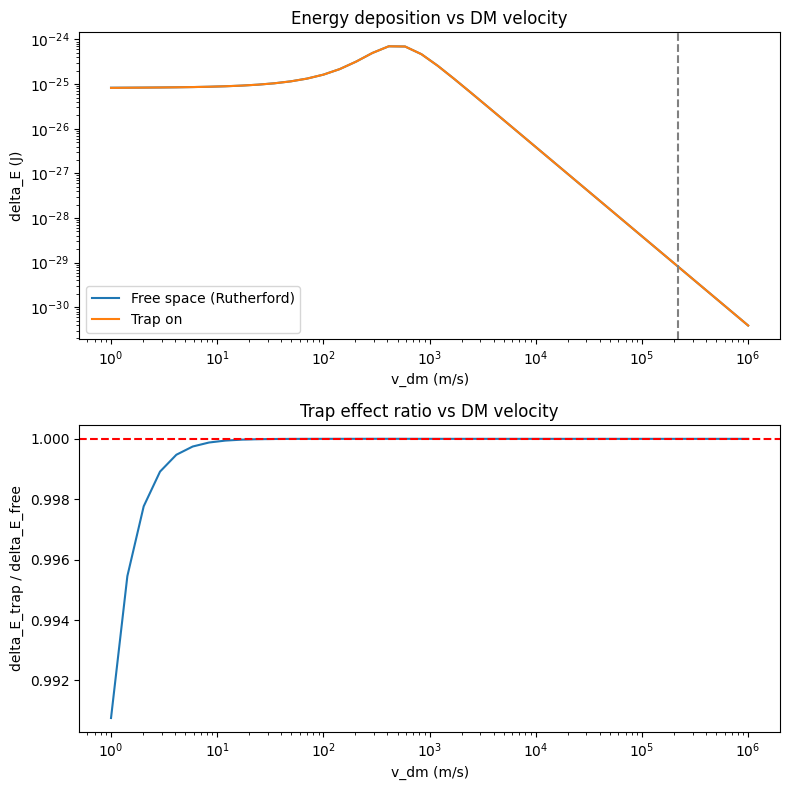

In [ ]:
v_dm_arr = np.logspace(0, 6, 40)  # 1 m/s to 1e6 m/s

dE_free = []
dE_trap = []

for v in v_dm_arr:
    dE_free.append(compute_delta_E(v, b_default, m_dm, eps, run_rutherford=True))
    dE_trap.append(compute_delta_E(v, b_default, m_dm, eps, run_rutherford=False))

dE_free = np.array(dE_free)
dE_trap = np.array(dE_trap)
ratio_v = dE_trap / dE_free

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.loglog(v_dm_arr, dE_free, label='Free space (Rutherford)')
ax1.loglog(v_dm_arr, dE_trap, label='Trap on')
ax1.set_xlabel('v_dm (m/s)')
ax1.set_ylabel('delta_E (J)')
ax1.set_title('Energy deposition vs DM velocity')
ax1.legend()
ax1.axvline(x=220e3, color='gray', linestyle='--', label='Galactic v_dm')

ax2.semilogx(v_dm_arr, ratio_v)
ax2.axhline(y=1, color='r', linestyle='--')
ax2.set_xlabel('v_dm (m/s)')
ax2.set_ylabel('delta_E_trap / delta_E_free')
ax2.set_title('Trap effect ratio vs DM velocity')

plt.tight_layout()
plt.savefig('sweep_vdm.png', dpi=150)
plt.show()


## Sweep 2: impact parameter b sweep

Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.09090909090909e-16
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.09090909090909e-16
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.1489521937458794e-15
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1.1489521937458794e-15
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver su

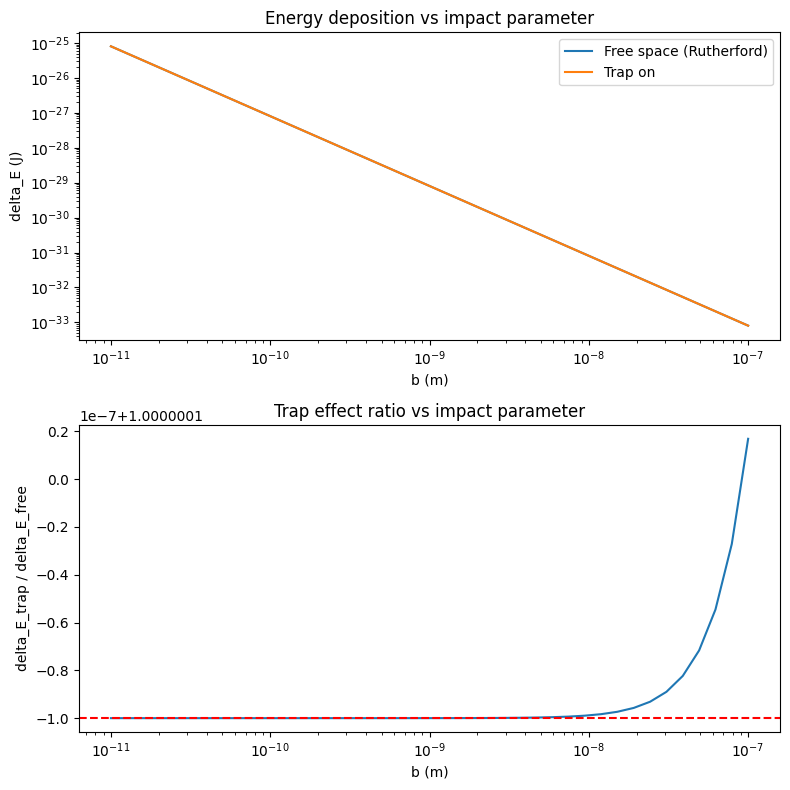

In [ ]:
b_arr = np.logspace(-11, -7, 40)  # meters

dE_free_b = []
dE_trap_b = []

for b in b_arr:
    dE_free_b.append(compute_delta_E(v_dm_default, b, m_dm, eps, run_rutherford=True))
    dE_trap_b.append(compute_delta_E(v_dm_default, b, m_dm, eps, run_rutherford=False))

dE_free_b = np.array(dE_free_b)
dE_trap_b = np.array(dE_trap_b)
ratio_b = dE_trap_b / dE_free_b

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.loglog(b_arr, dE_free_b, label='Free space (Rutherford)')
ax1.loglog(b_arr, dE_trap_b, label='Trap on')
ax1.set_xlabel('b (m)')
ax1.set_ylabel('delta_E (J)')
ax1.set_title('Energy deposition vs impact parameter')
ax1.legend()

ax2.semilogx(b_arr, ratio_b)
ax2.axhline(y=1, color='r', linestyle='--')
ax2.set_xlabel('b (m)')
ax2.set_ylabel('delta_E_trap / delta_E_free')
ax2.set_title('Trap effect ratio vs impact parameter')

plt.tight_layout()
plt.savefig('sweep_b.png', dpi=150)
plt.show()


## Sweep 3: trap frequency sweep (omega_sec axial)



Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.072727272727272e-14
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.072727272727272e-14
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.072727272727272e-14
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.072727272727272e-14
Number of DM particles: 1
Initial ion position: [0. 0. 0.]
Initial ion velocity: [0. 0. 0.]
Success? True
Message: The solver su

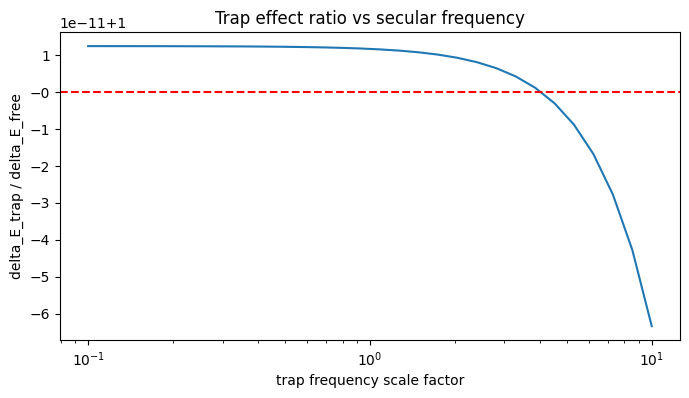

In [ ]:
freq_scales = np.logspace(-1, 1, 30)

dE_trap_freq = []

for scale in freq_scales:
    # temporarily scale omega_vec
    omega_vec_orig = omega_vec.copy()
    omega_vec[:] = omega_vec_orig * scale
    dE_trap_freq.append(compute_delta_E(v_dm_default, b_default, m_dm, eps, run_rutherford=False))
    omega_vec[:] = omega_vec_orig  

dE_trap_freq = np.array(dE_trap_freq)
dE_free_ref = compute_delta_E(v_dm_default, b_default, m_dm, eps, run_rutherford=True)

plt.figure(figsize=(8, 4))
plt.semilogx(freq_scales, dE_trap_freq / dE_free_ref)
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel('trap frequency scale factor')
plt.ylabel('delta_E_trap / delta_E_free')
plt.title('Trap effect ratio vs secular frequency')
plt.savefig('sweep_trapfreq.png', dpi=150)
plt.show()


In [ ]:
import os
import multiprocessing
print("CPU count:", os.cpu_count())
print("Usable cores:", multiprocessing.cpu_count())

CPU count: 16
Usable cores: 16
